## Decision Tree
- It is a **non parametric** supervised learning algorithm used for **classification** and **regression**
- has a hierarchical tree structure which starting from a **root node**, then has branches, internal nodes and leaf nodes
- splits the dataset based on feature values
- 
- We have two popular attribute selection measures used:
    - Information Gain tells us how useful a question (or feature) is for splitting data into groups.
    - We then select the split that yields the largest reduction in entropy, or equivalently, the largest increase in information.
    - 
    - Gini Index/Impurity - to measure how often a randomly chosen element would be incorrectly identified
        - helps us understand the "purity" of the nodes
        - **Gini impurity** for a node is the weighted average of the impurity of both the datasets of split
        - Attribute/Criteria with a lower Gini impurity should be preferred


Resource 1: https://www.analyticsvidhya.com/blog/2021/08/decision-tree-algorithm/

Resource 2: https://www.geeksforgeeks.org/machine-learning/decision-tree-introduction-example/

### A Breast Cancer Detection - Mini Project

In [257]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
# classification evaluation metrics are needed here
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [234]:
# Feature Selection - already done by sklearn
X = load_breast_cancer().data

y = load_breast_cancer().target
# malignant or Benign
# Cancer - moving around cancer cell === Benign means local and dead

# -----
column_names = load_breast_cancer().feature_names

df = pd.DataFrame(X, columns= column_names)
df['target'] = y

df.sample(5)

In [235]:
# train test split - 
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size= 0.2,
                                                    random_state = 42,
                                                    #stratify = y # homework for today
                                                    )

print(f"Train size => {X_train.shape}")
print(f"Target for Train, size => {y_train.shape}")

print(f"Test size => {X_test.shape}")
print(f"Target for Test, size => {y_test.shape}")

Train size => (455, 30)
Target for Train, size => (455,)
Test size => (114, 30)
Target for Test, size => (114,)


In [236]:
# modelling step - we choose our model 
# we can adjust some knobs in these models
# these are called Model Hyperparameters

model_tree = DecisionTreeClassifier(
    max_depth = 3, # depth is small
    criterion= 'gini', # gini entropy or log-loss
    random_state = 42
)

# train the model
model_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [237]:
# make predictions

y_pred_test = model_tree.predict(X_test) # unseen data
y_pred_train = model_tree.predict(X_train) # model has seeen these inputs

# Evaluation of the model
test_acc = accuracy_score(y_test, y_pred_test) # Testing accuracy
train_acc = accuracy_score(y_train, y_pred_train) #  Training accuracy

print("====== Model Evaluation ======")
print(f"Testing Accuracy: {test_acc*100:.2f}%")
print(f"Training Accuracy: {train_acc*100:.2f}%")

====== Model Evaluation ======
Testing Accuracy: 94.74%
Training Accuracy: 97.80%


- Overfitting - whether the model is doing better on training and worse on testing
    - give away is, close to 100% in training and bad in testing
    

In [238]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("---------------Confusion Matrix--------------\n",cm)

---------------Confusion Matrix--------------
 [[39  4]
 [ 2 69]]


In [239]:
# Classification Report
cr = classification_report(y_test, y_pred_test)
print("---------------Classification Report--------------\n",cr)

---------------Classification Report--------------
               precision    recall  f1-score   support

           0       0.95      0.91      0.93        43
           1       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



### Visualizing the Decision Tree

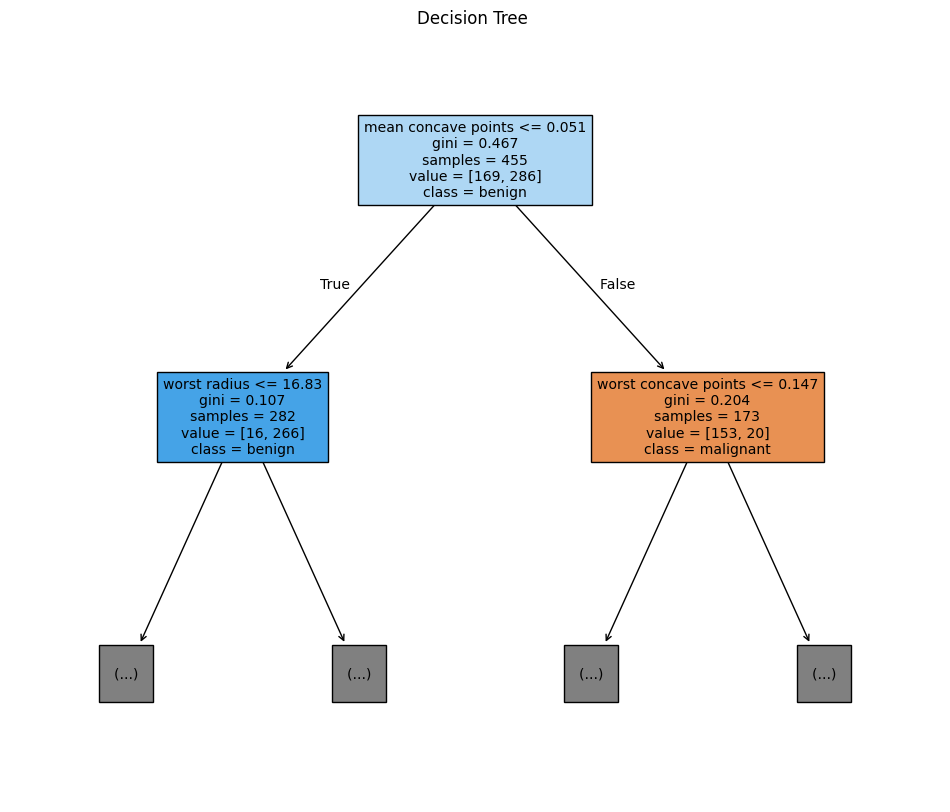

In [249]:
plt.figure(figsize = (12, 10))

plot_tree(model_tree,
          feature_names= load_breast_cancer().feature_names,
          class_names= load_breast_cancer().target_names,
          filled= True,
          max_depth= 1
          )

plt.title("Decision Tree ")
plt.show()

In [259]:
importances = model_tree.feature_importances_
feature_names = load_breast_cancer().feature_names

df_feature_importance = pd.DataFrame({
    'features': feature_names,
    'importance': importances
})

df_top_features = df_feature_importance.sort_values(by= 'importance', ascending= False).head(7)
df_top_features

,features,importance
7,mean concave points,0.752304
27,worst concave points,0.071432
20,worst radius,0.056905
22,worst perimeter,0.056028
1,mean texture,0.030106
19,fractal dimension error,0.020188
13,area error,0.013038


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'mean concave points'),
  Text(1, 0, 'worst concave points'),
  Text(2, 0, 'worst radius'),
  Text(3, 0, 'worst perimeter'),
  Text(4, 0, 'mean texture'),
  Text(5, 0, 'fractal dimension error'),
  Text(6, 0, 'area error')])

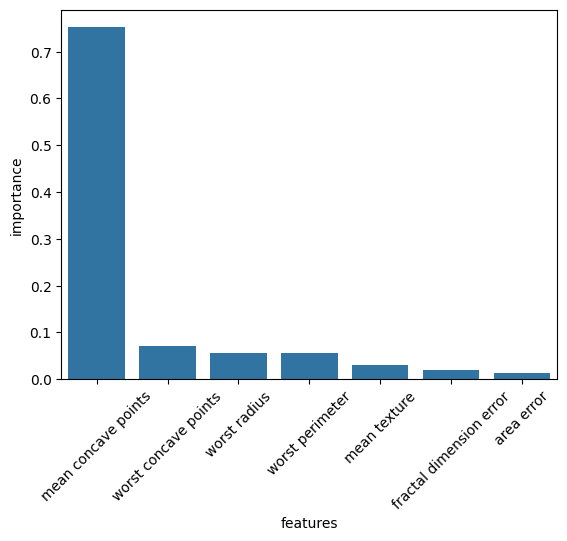

In [266]:
sns.barplot(df_top_features, x= 'features', y = 'importance')

plt.xticks(rotation = 45)

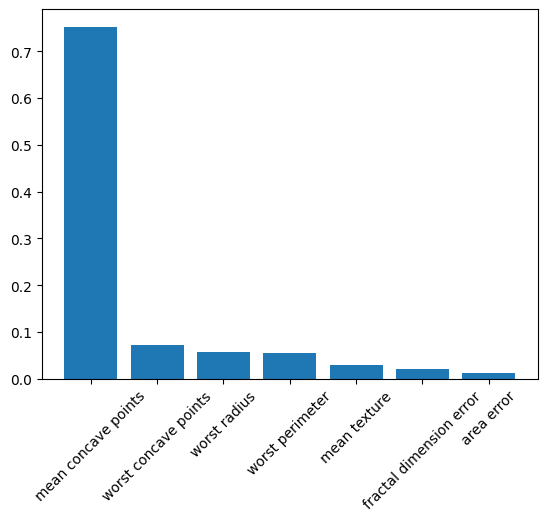

In [263]:
plt.bar(df_top_features['features'], df_top_features['importance'])

plt.xticks(rotation = 45)
plt.show()